# 05 - Market Share Analysis

Purpose:
Show how HealthSynth generates baseline and adjusted market share over time.

Important note:
In this version, market share is generated as a separate analytical table. Prescription generation does not yet consume adjusted market share directly.

## Market Share and Prescriptions

In this version, adjusted market share is used during prescription generation.
Products with higher adjusted market share should generally receive higher prescription volume, all else being equal.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

In [2]:
datasets = generate(
    config_path="../configs/profiles/oncology_training.yaml",
    output_dir="../output/market_share_analysis",
)

In [3]:
products = datasets["product"]
market_share = datasets["market_share"]

products

,market_id,product_id,product_name,therapeutic_area,launch_date,market,status,manufacturer,brand_type,baseline_market_share
0,MKT_ONC_CA,P001,OncoNova,Oncology,2023-01-01,Canada,Active,NVA Pharma,Innovator,0.45
1,MKT_ONC_CA,P002,Tumora,Oncology,2022-07-01,Canada,Active,Competitor A,Competitor,0.35
2,MKT_ONC_CA,P003,Immunex,Oncology,2021-01-01,Canada,Active,Competitor B,Competitor,0.20


In [4]:
market_share.head()

,market_id,month,therapeutic_area,product_id,baseline_market_share,adjusted_market_share
0,MKT_ONC_CA,2023-01-01,Oncology,P001,0.45,0.462103
1,MKT_ONC_CA,2023-01-01,Oncology,P002,0.35,0.348197
2,MKT_ONC_CA,2023-01-01,Oncology,P003,0.20,0.189701
3,MKT_ONC_CA,2023-02-01,Oncology,P001,0.45,0.461980
4,MKT_ONC_CA,2023-02-01,Oncology,P002,0.35,0.350828


In [5]:
market_share = market_share.merge(
    products[["product_id", "product_name", "manufacturer", "brand_type"]],
    on="product_id",
)
market_share["month"] = pd.to_datetime(market_share["month"])
market_share.head()

,market_id,month,therapeutic_area,product_id,baseline_market_share,adjusted_market_share,product_name,manufacturer,brand_type
0,MKT_ONC_CA,2023-01-01,Oncology,P001,0.45,0.462103,OncoNova,NVA Pharma,Innovator
1,MKT_ONC_CA,2023-01-01,Oncology,P002,0.35,0.348197,Tumora,Competitor A,Competitor
2,MKT_ONC_CA,2023-01-01,Oncology,P003,0.20,0.189701,Immunex,Competitor B,Competitor
3,MKT_ONC_CA,2023-02-01,Oncology,P001,0.45,0.461980,OncoNova,NVA Pharma,Innovator
4,MKT_ONC_CA,2023-02-01,Oncology,P002,0.35,0.350828,Tumora,Competitor A,Competitor


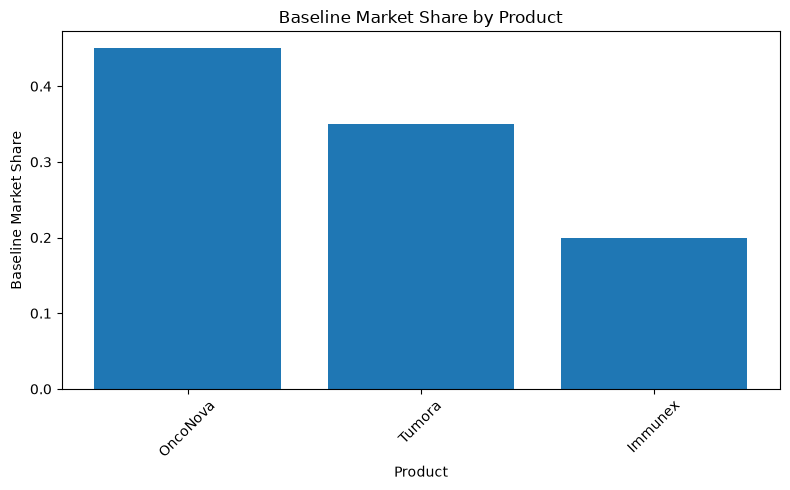

In [6]:
baseline = products[["product_name", "baseline_market_share"]].sort_values(
    "baseline_market_share", ascending=False
)

plt.figure(figsize=(8, 5))
plt.bar(baseline["product_name"], baseline["baseline_market_share"])
plt.title("Baseline Market Share by Product")
plt.xlabel("Product")
plt.ylabel("Baseline Market Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
pivot = market_share.pivot_table(
    index="month",
    columns="product_name",
    values="adjusted_market_share",
)

pivot.head()

product_name,Immunex,OncoNova,Tumora
month,,,
2023-01-01,0.189701,0.462103,0.348197
2023-02-01,0.187192,0.461980,0.350828
2023-03-01,0.206370,0.436481,0.357150
2023-04-01,0.203771,0.451970,0.344259
2023-05-01,0.209342,0.447667,0.342992


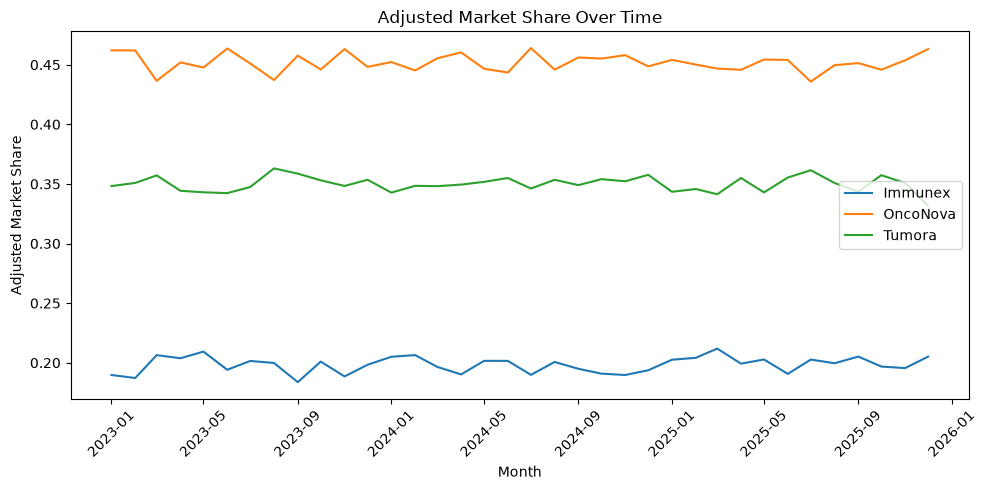

In [8]:
plt.figure(figsize=(10, 5))

for column in pivot.columns:
    plt.plot(pivot.index, pivot[column], label=column)

plt.title("Adjusted Market Share Over Time")
plt.xlabel("Month")
plt.ylabel("Adjusted Market Share")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
share_check = (
    market_share.groupby(["therapeutic_area", "month"])["adjusted_market_share"]
    .sum()
    .reset_index(name="total_share")
)

share_check.head()

,therapeutic_area,month,total_share
0,Oncology,2023-01-01,1.0
1,Oncology,2023-02-01,1.0
2,Oncology,2023-03-01,1.0
3,Oncology,2023-04-01,1.0
4,Oncology,2023-05-01,1.0


In [ ]:
rx = datasets["prescriptions"].merge(
    products[["product_id", "product_name", "manufacturer", "brand_type"]],
    on="product_id",
)

rx_by_product = (
    datasets["prescriptions"]
    .groupby("product_id")["nrx"]
    .sum()
    .reset_index()
    .merge(products[["product_id", "product_name", "baseline_market_share"]], on="product_id")
    .sort_values("nrx", ascending=False)
)

rx_by_product

,product_name,nrx
1,OncoNova,134959
2,Tumora,121648
0,Immunex,109601


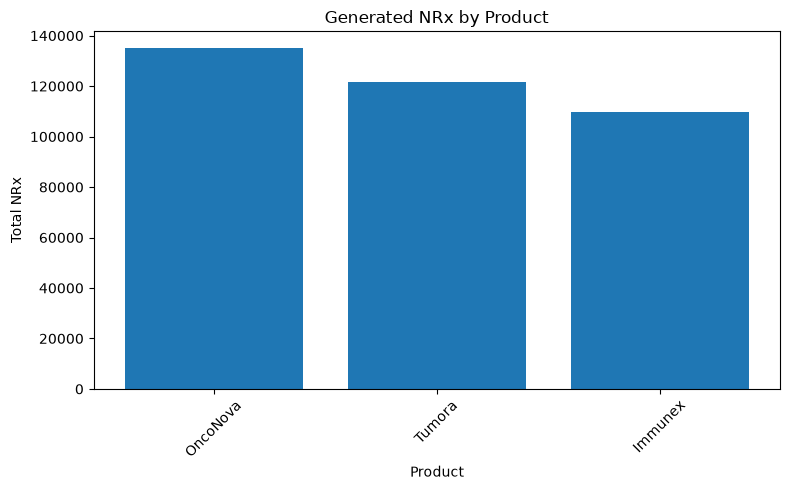

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(rx_by_product["product_name"], rx_by_product["nrx"])
plt.title("Generated NRx by Product")
plt.xlabel("Product")
plt.ylabel("Total NRx")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Takeaway

HealthSynth now generates a market_share table that captures baseline and adjusted product share over time.

This table is useful for learning:

- baseline share assumptions
- product competition
- month-by-month market movement
- how market share can be analyzed separately from prescription volume

In the current version, prescriptions are still generated independently from adjusted market share. A future version will use market share directly in prescription allocation.